In [49]:
# Import important library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import zscore

### Read the input file and check the data dimension

In [2]:
df = pd.read_csv("german_credit.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
default                       1000 non-null int64
account_check_status          1000 non-null object
duration_in_month             1000 non-null int64
credit_history                1000 non-null object
purpose                       1000 non-null object
credit_amount                 1000 non-null int64
savings                       1000 non-null object
present_emp_since             1000 non-null object
installment_as_income_perc    1000 non-null int64
personal_status_sex           1000 non-null object
other_debtors                 1000 non-null object
present_res_since             1000 non-null int64
property                      1000 non-null object
age                           1000 non-null int64
other_installment_plans       1000 non-null object
housing                       1000 non-null object
credits_this_bank             1000 non-null int64
job                           1000

In [4]:
df.head().T

,0,1,2,3,4
default,0,1,0,0,1
account_check_status,< 0 DM,0 <= ... < 200 DM,no checking account,< 0 DM,< 0 DM
duration_in_month,6,48,12,42,24
credit_history,critical account/ other credits existing (not ...,existing credits paid back duly till now,critical account/ other credits existing (not ...,existing credits paid back duly till now,delay in paying off in the past
purpose,domestic appliances,domestic appliances,(vacation - does not exist?),radio/television,car (new)
credit_amount,1169,5951,2096,7882,4870
savings,unknown/ no savings account,... < 100 DM,... < 100 DM,... < 100 DM,... < 100 DM
present_emp_since,.. >= 7 years,1 <= ... < 4 years,4 <= ... < 7 years,4 <= ... < 7 years,1 <= ... < 4 years
installment_as_income_perc,4,2,2,2,3
personal_status_sex,male : single,female : divorced/separated/married,male : single,male : single,male : single


In [5]:
df.shape

(1000, 21)

In [35]:
df.columns


Index(['default', 'duration_in_month', 'credit_amount',
       'installment_as_income_perc', 'present_res_since', 'age',
       'credits_this_bank', 'people_under_maintenance'],
      dtype='object')

In [7]:
# You can access from https://www.kaggle.com/uciml/german-credit
#Read input file and understand the data
# "default" is my dependent variable

### Q1 Randomly select 50% data for this use case( 1 Marks)
###### Hint: Use train_test_split

In [8]:
X = df.drop(labels= "default" , axis = 1)
y = df[["default"]]

In [9]:
test_size = 0.50 # taking 50:50 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [10]:
# Lets build a Ensemble model but need to modify the dataset first


### Q2.Prepare the model data by converting non-numeric to dummy ( 1 Marks)
##### Hint: Use get_dummies

In [11]:
# Print Shape of model data
X_train.shape

(500, 20)

In [12]:
X_train = pd.get_dummies(X_train, prefix=None, prefix_sep='_', dummy_na=False, columns=None, sparse=False, drop_first=False, dtype=None)

In [13]:
X_train.shape

(500, 61)

In [14]:
X_train.head().T

,262,457,82,563,407
duration_in_month,18,12,18,36,15
credit_amount,5302,3386,1568,12389,1053
installment_as_income_perc,2,3,3,1,4
present_res_since,4,4,4,4,2
age,36,35,24,37,27
credits_this_bank,3,1,1,1,1
people_under_maintenance,1,1,1,1,1
account_check_status_0 <= ... < 200 DM,0,0,0,1,0
account_check_status_< 0 DM,1,1,0,0,1
account_check_status_>= 200 DM / salary assignments for at least 1 year,0,0,0,0,0


### Check for highly correlated variables but don't required any treatment for this use case

In [15]:
X_train.corr()

,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance,account_check_status_0 <= ... < 200 DM,account_check_status_< 0 DM,account_check_status_>= 200 DM / salary assignments for at least 1 year,...,housing_own,housing_rent,job_management/ self-employed/ highly qualified employee/ officer,job_skilled employee / official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,telephone_none,"telephone_yes, registered under the customers name",foreign_worker_no,foreign_worker_yes
duration_in_month,1.000000,0.669686,0.061521,0.016471,-0.016886,-0.034892,-0.052569,0.114018,-0.020352,-0.069055,...,-7.916794e-02,-0.066980,0.107500,0.052840,-0.006085,-1.557128e-01,-0.148593,0.148593,-0.122827,0.122827
credit_amount,0.669686,1.000000,-0.254486,-0.024982,0.047257,-0.008663,-0.008651,0.143620,-0.056465,-0.098673,...,-1.172121e-01,-0.045493,0.334242,-0.107587,-0.051660,-1.429619e-01,-0.286036,0.286036,-0.004987,0.004987
installment_as_income_perc,0.061521,-0.254486,1.000000,0.046631,0.005176,0.013426,-0.066527,-0.067434,0.066033,-0.012067,...,2.418437e-02,-0.045652,0.024764,0.047316,-0.043179,-6.166971e-02,0.027533,-0.027533,-0.099614,0.099614
present_res_since,0.016471,-0.024982,0.046631,1.000000,0.298441,0.083938,0.062531,-0.120421,0.099763,-0.016563,...,-2.549124e-01,0.093396,0.056670,-0.068720,-0.033805,4.665443e-02,-0.147116,0.147116,-0.025856,0.025856
age,-0.016886,0.047257,0.005176,0.298441,1.000000,0.144156,0.116705,-0.088513,-0.003051,0.053409,...,2.890115e-03,-0.232857,0.193506,-0.220548,0.092830,5.942677e-02,-0.151331,0.151331,0.009335,-0.009335
credits_this_bank,-0.034892,-0.008663,0.013426,0.083938,0.144156,1.000000,0.090760,-0.134189,-0.008866,-0.101759,...,4.154080e-02,-0.097184,0.018928,0.008244,0.063727,-5.191741e-02,-0.041090,0.041090,-0.024385,0.024385
people_under_maintenance,-0.052569,-0.008651,-0.066527,0.062531,0.116705,0.090760,1.000000,-0.106872,0.076662,-0.028040,...,-2.904670e-02,-0.077498,0.011526,-0.105317,-0.040484,1.331087e-01,-0.005313,0.005313,0.099226,-0.099226
account_check_status_0 <= ... < 200 DM,0.114018,0.143620,-0.067434,-0.120421,-0.088513,-0.134189,-0.106872,1.000000,-0.373070,-0.150809,...,-1.600051e-02,0.017125,0.059625,-0.044042,0.019352,-6.874084e-03,-0.009630,0.009630,-0.054576,0.054576
account_check_status_< 0 DM,-0.020352,-0.056465,0.066033,0.099763,-0.003051,-0.008866,0.076662,-0.373070,1.000000,-0.163512,...,-1.233656e-01,0.096931,-0.046998,-0.006587,0.034859,3.533326e-02,0.112097,-0.112097,0.060026,-0.060026
account_check_status_>= 200 DM / salary assignments for at least 1 year,-0.069055,-0.098673,-0.012067,-0.016563,0.053409,-0.101759,-0.028040,-0.150809,-0.163512,1.000000,...,-3.076607e-02,0.006335,-0.034582,-0.026282,0.062226,3.732031e-02,0.060560,-0.060560,0.000377,-0.000377


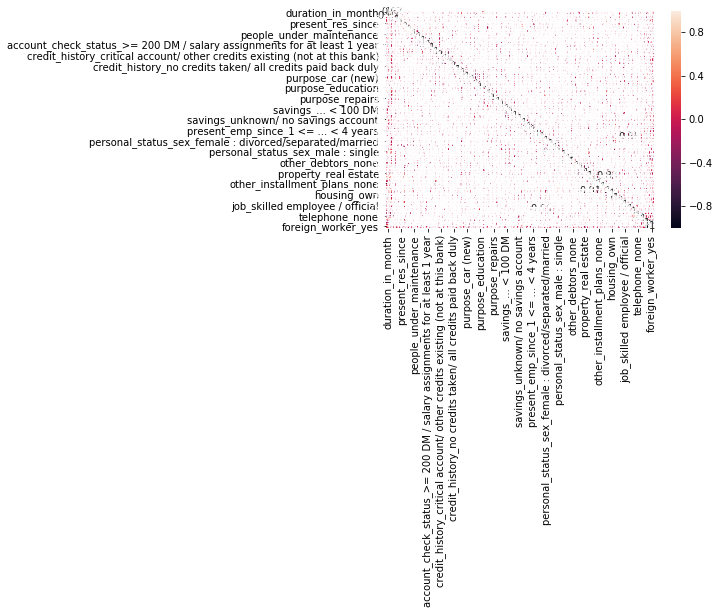

In [26]:
sns.heatmap(X_train.corr(), annot=True)

### Drop the original variables which are converted to dummy

In [38]:
df.drop(['account_check_status','credit_history','purpose','savings','present_emp_since','personal_status_sex','other_debtors','property','other_installment_plans','housing','job','telephone','foreign_worker'],axis=1,inplace=True)

,default,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance
0,0,6,1169,4,4,67,2,1
1,1,48,5951,2,2,22,1,1
2,0,12,2096,2,3,49,1,2
3,0,42,7882,2,4,45,1,2
4,1,24,4870,3,4,53,2,2
5,0,36,9055,2,4,35,1,2
6,0,24,2835,3,4,53,1,1
7,0,36,6948,2,2,35,1,1
8,0,12,3059,2,4,61,1,1
9,1,30,5234,4,2,28,2,1


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
default                       1000 non-null int64
duration_in_month             1000 non-null int64
credit_amount                 1000 non-null int64
installment_as_income_perc    1000 non-null int64
present_res_since             1000 non-null int64
age                           1000 non-null int64
credits_this_bank             1000 non-null int64
people_under_maintenance      1000 non-null int64
dtypes: int64(8)
memory usage: 62.6 KB


In [41]:
df.head().T

,0,1,2,3,4
default,0,1,0,0,1
duration_in_month,6,48,12,42,24
credit_amount,1169,5951,2096,7882,4870
installment_as_income_perc,4,2,2,2,3
present_res_since,4,2,3,4,4
age,67,22,49,45,53
credits_this_bank,2,1,1,1,2
people_under_maintenance,1,1,2,2,2


In [42]:
df.dropna(inplace=True)

### Q3 Split Train/Test data 70:30 ratio( 1 Marks)
##### Hint:from sklearn.model_selection import train_test_split

In [50]:

X = df.drop('default',axis=1)
y = df[['default']]
X = X.apply(zscore)

In [51]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=0)

### Q4 Build Random Forest Model( 1 Marks)
#### Hint:from sklearn.ensemble import RandomForestClassifier using n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999

In [57]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection
from sklearn import metrics,svm
from sklearn import preprocessing
from sklearn import utils
from sklearn.model_selection import GridSearchCV

In [64]:
Rf_model = RandomForestClassifier(n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999)

In [65]:
models = []
models.append(('RandomForest', Rf_model))

In [66]:

results = []
names = []
scoring = 'recall'
for name, model in models:
	kfold = model_selection.KFold(n_splits=5,random_state=2)
	cv_results = model_selection.cross_val_score(model, X, y, cv=kfold, scoring=scoring)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, np.mean(cv_results), cv_results.var())
	print(msg)

RandomForest: 0.272595 (0.005230)


In [68]:
Rf_model.fit(x_train, y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

In [69]:
results

[array([0.36842105, 0.33333333, 0.17391304, 0.27419355, 0.21311475])]

### Q5 Calculate Confusion Matrix and Accuracy score (1 Marks)
##### Hint: Use confusion_matrix and accuracy_score

In [71]:
Y_predict=Rf_model.predict(x_test)
cm=metrics.confusion_matrix(y_test,Y_predict)
cm

array([[186,  28],
       [ 61,  25]])

### Q6 Show the list of the features importance( 1 Marks)

In [73]:
feature_importances = pd.DataFrame(Rf_model.feature_importances_,
                                   index = x_train.columns,
                                    columns=['importance']).sort_values('importance', ascending=False)
feature_importances

,importance
credit_amount,0.335237
age,0.245015
duration_in_month,0.194081
present_res_since,0.081825
installment_as_income_perc,0.067107
credits_this_bank,0.049429
people_under_maintenance,0.027305


### Q7 K-fold cross-validation( 2 Marks)
##### k-fold cross validation( without stratification)
##### Usually k is set as 10-20 in practical settings, depends on data set size

In [74]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [81]:
# Use below values
num_folds = 10
seed = 77

In [19]:
#Validate the Random Forest model build above using k fold

In [95]:
Rf_model = RandomForestClassifier(n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999)

In [96]:
models = []
models.append(('RandomForest', Rf_model1))
results = []
names = []
scoring = 'recall'
for name, model1 in models1:
	kfold = model_selection.KFold(n_splits=num_folds,random_state=seed)
	cv_results = model_selection.cross_val_score(model, X, y, cv=kfold, scoring=scoring)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, np.mean(cv_results), cv_results.var())
	print(msg)

RandomForest: 0.275143 (0.008349)


In [98]:
Rf_model.fit(x_train, y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

In [99]:
results

[array([0.44      , 0.21875   , 0.2173913 , 0.35714286, 0.25      ,
        0.17073171, 0.3       , 0.40625   , 0.17241379, 0.21875   ])]

In [20]:
#Calculate Mean score

In [100]:
np.mean(results)

0.2751429661911205

In [21]:
# Calculate score standard deviation using std()

In [101]:
np.std(results)

0.09137368363235293

In [103]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = Rf_model, X = x_test, y = y_test, cv = num_folds)
print(accuracies.mean())
print(accuracies.std())

0.6807230255839821
0.05849405405943697


# Q8 Print the confusion matrix( 1 Marks)

In [106]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_pred = cross_val_predict(estimator = Rf_model, X = x_test, y = y_test, cv = num_folds)
conf_mat = confusion_matrix(y_test, y_pred)

#Confusion Matrix
conf_mat

array([[192,  22],
       [ 74,  12]])

# Q9.Classification accuracy: 
percentage of correct predictions and Calculate sensitivity (or True Positive Rate or Recall) and Precision.
( 1 Marks)

In [107]:
# calculate accuracy
from sklearn import metrics
print(metrics.accuracy_score(y_test, y_pred))

print("Accuracy: %0.2f (+/- %0.2f)" % (accuracies.mean(), accuracies.std() * 2))

#print(metrics.confusion_matrix(y_train, y_pred))

TP = conf_mat[1, 1]
TN = conf_mat[0, 0]
FP = conf_mat[0, 1]
FN = conf_mat[1, 0]

#TP = 12
#TN = 192
#FP = 22
#FN = 74

print(' Percentage of correct predictions:  ',((TP + TN) / float(TP + TN + FP + FN) * 100))

0.68
Accuracy: 0.68 (+/- 0.12)
 Percentage of correct predictions:   68.0


In [108]:
#Sensitivity
sensitivity = TP / float(FN + TP)

print(sensitivity)
print(metrics.recall_score(y_test, y_pred))

0.13953488372093023
0.13953488372093023


# Q10.Plot Receiver Operating Characteristic (ROC) Curves( 1 Marks)

In [22]:
#Hint: Use roc_curve

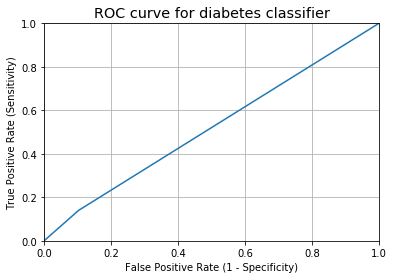

In [109]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)

plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.rcParams['font.size'] = 12
plt.title('ROC curve for diabetes classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)

ROC curve can help you to choose a threshold that balances sensitivity and specificity in a way that makes sense for your particular context

# Q11. Calculate AUC(the percentage of the ROC plot that is underneath the curve) - optional

In [110]:
print(metrics.roc_auc_score(y_test, y_pred))

0.5183655727015866


### Bootstrapping ( Bonus)
##### Given a dataset of size n, a bootstrap sample is created by sampling n instances uniformly from the data (with/without replacement)
##### Create a model with each bootstrap sample and validate it with the test set
##### Final result is calculated by averaging the accuracy of models

In [111]:
# Number of iterations for bootstrapping
bootstrap_iteration = 10
accuracy = []

In [114]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

for i in range(bootstrap_iteration):
    X_, y_ = resample(x_train, y_train)
    Rf_model.fit(X_, y_)
    y_pred = Rf_model.predict(x_test)
    
    acc = accuracy_score(y_pred, y_test)
    accuracy.append(acc)

In [115]:
accuracy = np.array(accuracy)
print('Accuracy Score')
print('Avearge: ', accuracy.mean())
print('Standard deviation: ', accuracy.std())

Accuracy Score
Avearge:  0.7023333333333334
Standard deviation:  0.01282792093659592
